In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings


In [2]:
HOME = "/scistor/ivm/the410/"

#HOME = "/home/thappe/" #snellius

In [3]:
os.chdir(f"{HOME}HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *

In [5]:
pwd

'/scistor/ivm/the410/VAE3D/autoencoder_notebooks/LatentSpace/P1'

In [5]:
### GLOBAL VARIABLES snellius

# os.chdir(HOME)

# data_path = "/home/thappe/data"
# data_path_heatwaves = f"{data_path}/heatwaves/"
# data_path_climate = data_path


In [6]:
### GLOBAL VARIABLES IVM

os.chdir(HOME)

#IVM 
data_path = "/scistor/ivm/the410/PAPER3"

#SNELLIUS
# data_path = "/home/thappe/data/MODEL_VAE"

In [7]:
ls /scistor/ivm/the410/PAPER3

ERA5_t2m_minus_thermo_encoded_heatwaves_L128.csv
ERA5_t2m_minus_thermo_encoded_heatwaves_L128_noheader.csv
GMM.pkl
Kmeanseucl.pkl
t2m_data_from_snellius_for_gdbscan/
tf_records/
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


## LOADING DATA 

In [8]:
t2m_name = "t2m" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5")

In [9]:
##load heatwave means from csv and datetime information 

heatwave_means = pd.read_csv(f'{data_path}/ERA5_{t2m_name}_encoded_heatwaves_L{VAE_model[0]}.csv')

heatwave_dates = pd.read_csv(f'{data_path}/ERA5_{t2m_name}_heatwaves_dates.csv')

2025-03-19 09:59:36.693419: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-03-19 09:59:36.693480: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: node013
2025-03-19 09:59:36.693489: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: node013
2025-03-19 09:59:36.693614: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 550.54.15
2025-03-19 09:59:36.693633: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 550.54.15
2025-03-19 09:59:36.693638: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 550.54.15


In [ ]:
## dates in correct format? 

In [16]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

### bij welk cluster horen de heatwaves?

In [25]:
heatwave_means

array([ 1.1091595 , -0.49508706,  0.40897438,  0.8974355 ,  0.19032468,
        0.7714641 ,  2.07929   , -0.4397501 , -1.3065593 ,  0.5271634 ,
       -2.6210034 ,  0.5024593 ,  0.6392352 ,  0.6655764 , -0.46631023,
        0.5811173 ,  2.4128637 ,  0.7351508 , -0.58341897,  1.1729548 ,
       -0.47975028,  0.7085057 ,  0.73444945, -0.4702311 , -0.43640643,
       -0.6239401 , -2.0105667 , -0.8150123 , -0.30229607, -2.7790174 ,
        0.3548306 , -1.3334208 ,  1.3284944 , -0.08923689,  0.58923787,
        1.7836196 , -0.26438856,  1.6155093 , -0.72140634, -0.45053995,
       -1.1958696 , -0.68308204,  2.79305   , -0.78627986, -0.02987562,
        0.20385922, -0.48647374, -3.6597307 , -0.48939168,  0.1823532 ,
        1.1504198 ,  1.6547153 ,  1.1760782 , -0.38526157, -1.3304876 ,
        0.11990003,  0.8019634 ,  0.6850579 , -0.8143528 ,  0.03121793,
       -1.8029584 , -1.0858666 ,  0.8555274 , -1.2319669 ,  0.43533093,
       -1.8878994 ,  1.2573333 , -1.6369095 , -3.2489388 , -1.31

In [52]:
## load kmeans / GMM 

import pickle
import scipy


to_cluster = np.array(heatwave_means)

## to open the GM model
f=f'{data_path}/GMM.pkl'
GM = pickle.load(open(f, 'rb'))

## predict heatwave clusters 
y_pred_GM = GM.fit_predict(to_cluster)

#to get individual probabilities of belonging to cluster
probs = GM.predict_proba(to_cluster)

#to get the centers
GM_centers = np.empty(shape=(GM.n_components, to_cluster.shape[1]))
for i in range(GM.n_components):
    density = scipy.stats.multivariate_normal(cov=GM.covariances_[i], mean=GM.means_[i]).logpdf(to_cluster)
    GM_centers[i, :] = to_cluster[np.argmax(density)]

In [ ]:
## TSNE space? 

## clusters over time



In [178]:
## plotting over time

In [53]:
from datetime import date
dates = []
for element in data_parsed.as_numpy_iterator(): #to convert to numpy elements
    array = np.transpose(element[0])
    stream_in = array[0, :, :, :] 
    psl_in = array[1, :, :, :]
    iso_date = date(element[1], element[2], element[3]).isoformat() #year, month, date 
    date_date = date.fromisoformat(iso_date) #to datetime object 
    dates.append(date_date)

In [54]:
dates[-10:]

[datetime.date(2023, 7, 8),
 datetime.date(2023, 7, 12),
 datetime.date(2023, 7, 15),
 datetime.date(2023, 8, 2),
 datetime.date(2023, 8, 6),
 datetime.date(2023, 8, 10),
 datetime.date(2023, 8, 13),
 datetime.date(2023, 8, 17),
 datetime.date(2023, 8, 18),
 datetime.date(2023, 8, 26)]

In [55]:
## initialize empty dictionary 
year_counts = {}
for year in np.arange(1940, 2024, 1):
    year_counts[year] = {1:0, 2:0, 3:0, 4:0}
    

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts[date.year][cluster_id] += 1 #add one to this year and cluster count

In [56]:
year_counts_reversed = {}
for cluster_id in [1,2,3,4]:
    cluster_ids = {}
    for year in np.arange(1940, 2024, 1):
        cluster_ids[year] = 0
    year_counts_reversed[cluster_id] = cluster_ids

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts_reversed[cluster_id][date.year] += 1 #add one to this year and cluster count
    

In [57]:
year_counts_for_plotting = {}

for year in np.arange(1940, 2024, 1):
    year_counts_for_plotting[year] = [0,0,0,0]

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts_for_plotting[date.year][cluster] += 1 #add one to this year and cluster count
    
# year_counts_for_plotting

In [58]:
years = np.arange(1940, 2024, 1)
year_counts_for_plotting_reversed  = {}


for cluster_id in [1,2,3,4]:
    year_counts_for_plotting_reversed[cluster_id] = np.zeros_like(years)
    

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_index = np.where(years==date.year)
    year_counts_for_plotting_reversed[cluster_id][year_index] += 1 #add one to this year and cluster count
    
# year_counts_for_plotting_reversed

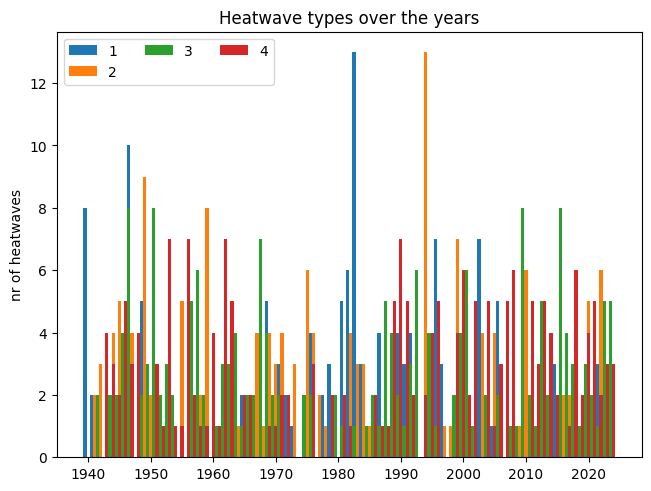

In [59]:
years = np.arange(1940, 2024, 1)

x = np.arange(len(years))  # the label locations
width = 0.5  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for cluster_id, counts in year_counts_for_plotting_reversed.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=cluster_id)
#     ax.bar_label(rects, padding=3)
    multiplier += 1

# # Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('nr of heatwaves')
ax.set_title('Heatwave types over the years')
ax.set_xticks(np.arange(len(np.arange(1940,2024,10)))*10 +width, np.arange(1940,2024,10))
ax.legend(loc='upper left', ncols=3)

plt.show()

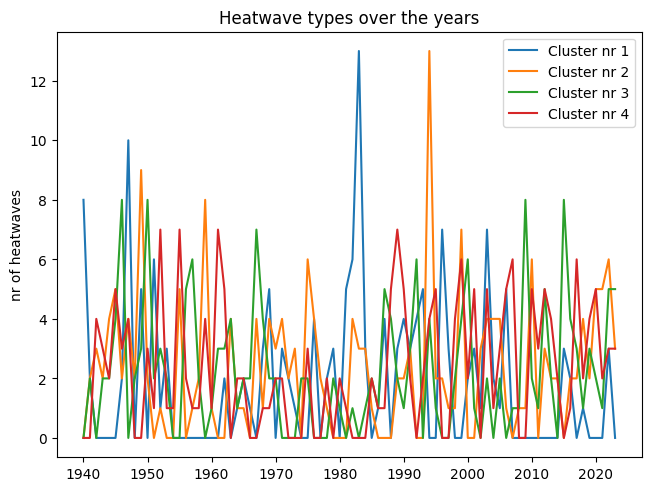

In [60]:
years = np.arange(1940, 2024, 1)

fig, ax = plt.subplots(layout='constrained')

for cluster_id, counts in year_counts_for_plotting_reversed.items():
    ax.plot(years, counts, label=f"Cluster nr {cluster_id}")
    
# # Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('nr of heatwaves')
ax.set_title('Heatwave types over the years')
ax.set_xticks(np.arange(1940,2024,10))
ax.legend(loc='upper right', ncols=1)

plt.show()

1
2
3
4


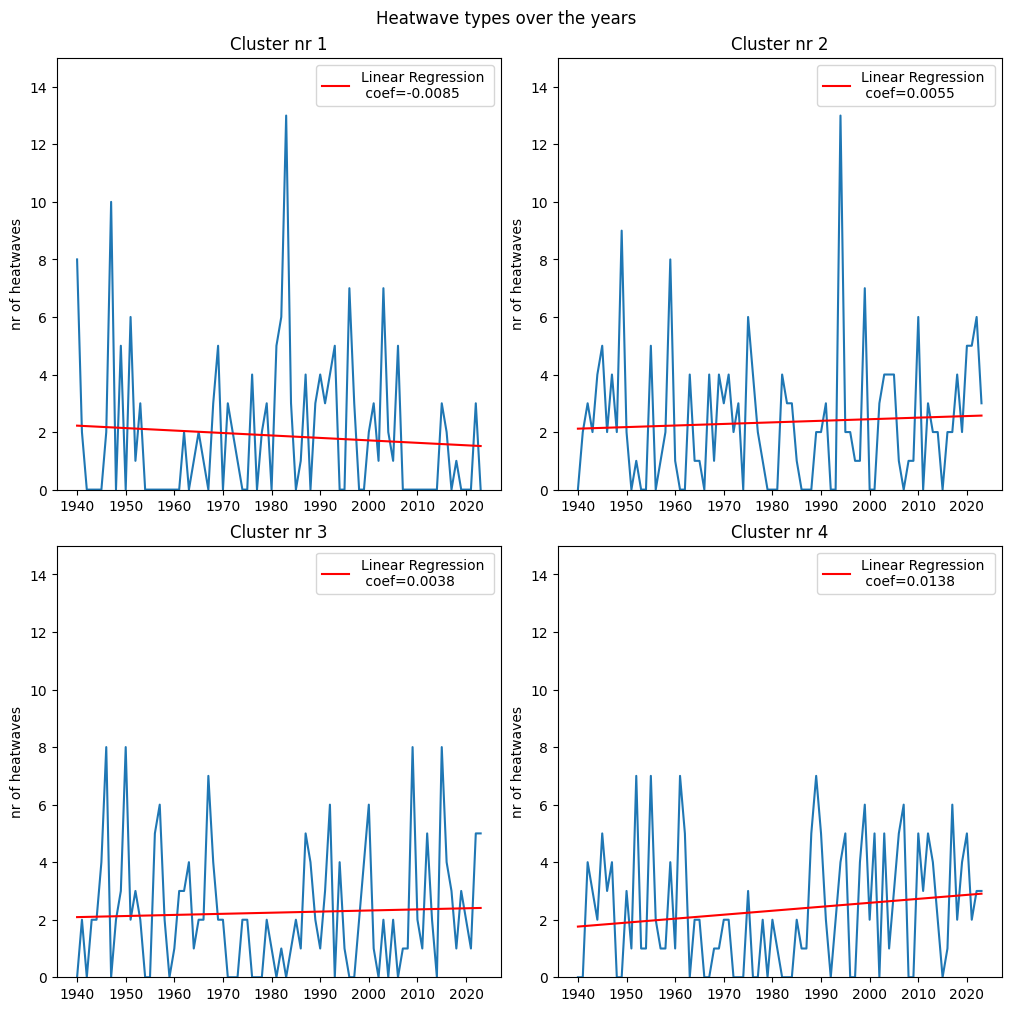

In [72]:
years = np.arange(1940, 2024, 1)

fig, axes = plt.subplots(2,2, figsize=(10,10), layout='constrained')

for cluster_id, ax in zip([1,2,3,4], axes.flatten()):
    print(cluster_id)

    ax.plot(years, year_counts_for_plotting_reversed[cluster_id]) #, label=f"Cluster nr {cluster_id}")

    from sklearn.linear_model import LinearRegression
    reg = LinearRegression().fit(years.reshape(-1, 1), year_counts_for_plotting_reversed[cluster_id])
    Y = reg.predict(years.reshape(-1, 1))
    ax.plot(years, Y, label=f"Linear Regression \n coef={round(reg.coef_[0], 4)}", c="red")

    # # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('nr of heatwaves')
    ax.set_title(f"Cluster nr {cluster_id}")
    ax.set_xticks(np.arange(1940,2024,10))
    ax.legend(loc='upper right', ncols=1)
    ax.set_ylim(0,15)
    
fig.suptitle('Heatwave types over the years')
plt.show()

In [73]:
## next to plot central heatwaves